In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aniruddhsharma/structural-defects-network-concrete-crack-images")

print("Path to dataset files:", path)



100%|██████████| 506M/506M [00:15<00:00, 34.2MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
from torchvision.transforms import transforms
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
from torch.optim import Adam
import pandas as pd
import numpy as np
import os


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
device

'cuda'

In [6]:
from pathlib import Path

for item in Path(path).iterdir():
    print(item)

/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Decks
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Pavements


In [9]:
from pathlib import Path

root = Path("/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1")

for item in root.iterdir():
    print(item)

/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Decks
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Pavements


In [10]:
for item in (root/"Decks").iterdir():
    print(item)

/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Decks/Non-cracked
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Decks/Cracked


In [11]:
for item in (root/"Walls").iterdir():
    print(item)

/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Non-cracked
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Walls/Cracked


In [12]:
for item in (root/"Pavements").iterdir():
    print(item)

/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Pavements/Non-cracked
/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1/Pavements/Cracked


In [13]:
import os
import pandas as pd

image_paths = []
labels = []
surface_types = []

root = "/root/.cache/kagglehub/datasets/aniruddhsharma/structural-defects-network-concrete-crack-images/versions/1"

for surface in os.listdir(root):

    surface_path = os.path.join(root, surface)

    if not os.path.isdir(surface_path):
        continue

    # Cracked / Non-cracked
    for label in os.listdir(surface_path):

        label_path = os.path.join(surface_path, label)

        if not os.path.isdir(label_path):
            continue

        for image in os.listdir(label_path):

            if image.lower().endswith((".jpg", ".jpeg", ".png")):

                image_paths.append(os.path.join(label_path, image))
                labels.append(label)
                surface_types.append(surface)

df = pd.DataFrame({
    "image_path": image_paths,
    "surface": surface_types,
    "label": labels
})

print(df.head())
print(df.shape)
print(df["label"].value_counts())
print(df["surface"].value_counts())

                                          image_path surface        label
0  /root/.cache/kagglehub/datasets/aniruddhsharma...   Decks  Non-cracked
1  /root/.cache/kagglehub/datasets/aniruddhsharma...   Decks  Non-cracked
2  /root/.cache/kagglehub/datasets/aniruddhsharma...   Decks  Non-cracked
3  /root/.cache/kagglehub/datasets/aniruddhsharma...   Decks  Non-cracked
4  /root/.cache/kagglehub/datasets/aniruddhsharma...   Decks  Non-cracked
(56092, 3)
label
Non-cracked    47608
Cracked         8484
Name: count, dtype: int64
surface
Pavements    24334
Walls        18138
Decks        13620
Name: count, dtype: int64


In [14]:
df.head()

,image_path,surface,label
0,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
1,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
2,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
3,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
4,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked


In [15]:
df

,image_path,surface,label
0,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
1,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
2,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
3,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
4,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,Non-cracked
...,...,...,...
56087,/root/.cache/kagglehub/datasets/aniruddhsharma...,Pavements,Cracked
56088,/root/.cache/kagglehub/datasets/aniruddhsharma...,Pavements,Cracked
56089,/root/.cache/kagglehub/datasets/aniruddhsharma...,Pavements,Cracked
56090,/root/.cache/kagglehub/datasets/aniruddhsharma...,Pavements,Cracked


In [17]:
df.shape

(56092, 3)

In [18]:
df.isna().sum()

,0
image_path,0
surface,0
label,0


In [19]:
df.isnull().sum()

,0
image_path,0
surface,0
label,0


In [20]:
df['label'].value_counts()

,count
label,
Non-cracked,47608
Cracked,8484


In [21]:
df['surface'].value_counts()

,count
surface,
Pavements,24334
Walls,18138
Decks,13620


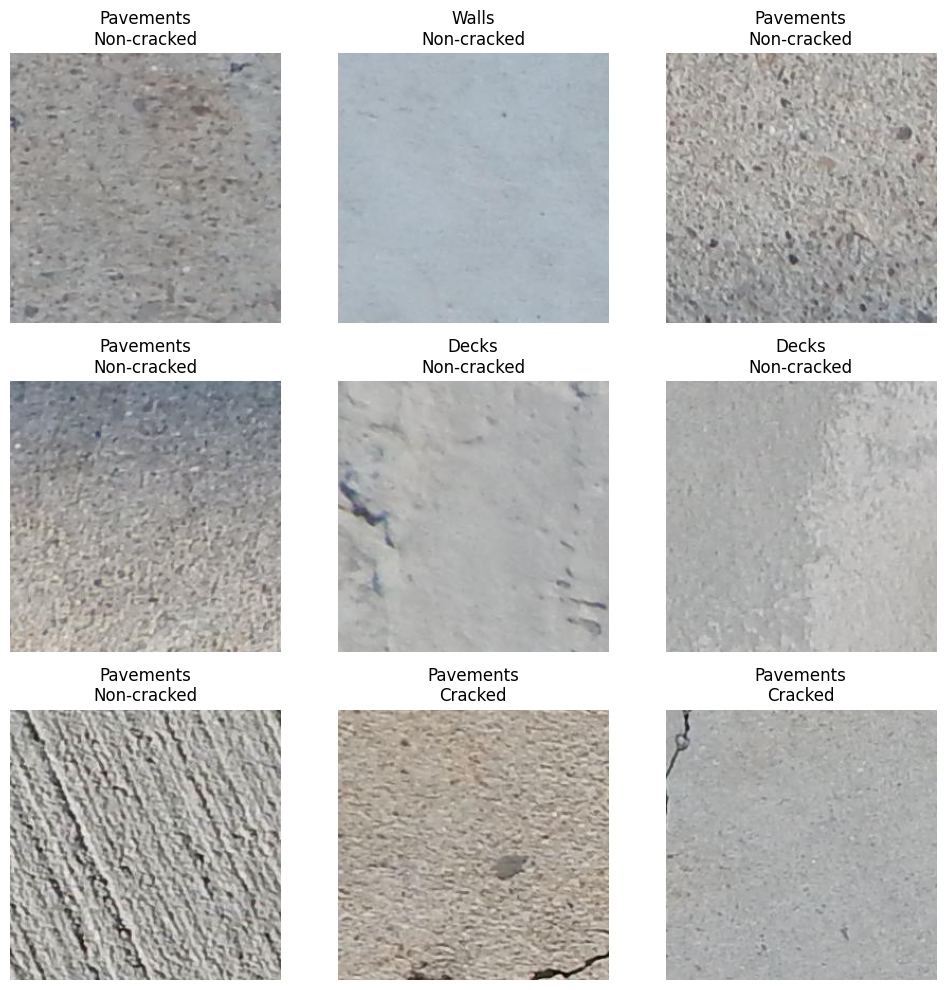

In [22]:
import matplotlib.pyplot as plt
from PIL import Image
import random

fig, axes = plt.subplots(3,3, figsize=(10,10))

for ax in axes.ravel():
    idx = random.randint(0, len(df)-1)

    img = Image.open(df.iloc[idx]["image_path"])

    ax.imshow(img)
    ax.set_title(
        f'{df.iloc[idx]["surface"]}\n{df.iloc[idx]["label"]}'
    )
    ax.axis("off")

plt.tight_layout()

In [23]:
from PIL import Image

sizes = []

for path in df["image_path"][:500]:
    img = Image.open(path)
    sizes.append(img.size)

sizes[:10]

[(256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256),
 (256, 256)]

In [24]:
from sklearn.preprocessing import LabelEncoder
ls = LabelEncoder()
df['label'] = ls.fit_transform(df['label'])

In [25]:
df['label']

,label
0,1
1,1
2,1
3,1
4,1
...,...
56087,0
56088,0
56089,0
56090,0


In [29]:
for class_name, encoded in zip(ls.classes_, ls.transform(ls.classes_)):
    print(f"{class_name} -> {encoded}")

Cracked -> 0
Non-cracked -> 1


In [30]:
from sklearn.model_selection import train_test_split
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label"]
)

In [31]:
## Transform the Image
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [36]:


class CrackedDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

        self.labels = torch.tensor(
            self.dataframe["label"].values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        img_path = self.dataframe.loc[idx, "image_path"]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [41]:
train_dataset = CrackedDataset(
    dataframe=train_df,
    transform=train_transform
)

val_dataset = CrackedDataset(
    dataframe=val_df,
    transform=test_transform
)

test_dataset = CrackedDataset(
    dataframe=test_df,
    transform=test_transform
)

In [42]:
train_df.head()

,image_path,surface,label
20703,/root/.cache/kagglehub/datasets/aniruddhsharma...,Walls,1
17302,/root/.cache/kagglehub/datasets/aniruddhsharma...,Walls,1
2386,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,1
2684,/root/.cache/kagglehub/datasets/aniruddhsharma...,Decks,1
15576,/root/.cache/kagglehub/datasets/aniruddhsharma...,Walls,1


In [43]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [45]:
import torch.nn as nn

class CrackCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(512, 2)
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [47]:
model = CrackCNN().to(device)

In [50]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(),lr = 0.001)

In [51]:
epochs = 10

In [52]:
train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):

    # ---------- Training ----------
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # ---------- Validation ----------
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-"*50)

Epoch 1/10
Train Loss: 0.4337 | Train Acc: 0.8484
Val Loss:   0.4266 | Val Acc:   0.8488
--------------------------------------------------
Epoch 2/10
Train Loss: 0.4024 | Train Acc: 0.8507
Val Loss:   0.3790 | Val Acc:   0.8646
--------------------------------------------------
Epoch 3/10
Train Loss: 0.3620 | Train Acc: 0.8701
Val Loss:   0.3279 | Val Acc:   0.8815
--------------------------------------------------
Epoch 4/10
Train Loss: 0.3362 | Train Acc: 0.8819
Val Loss:   0.3313 | Val Acc:   0.8833
--------------------------------------------------
Epoch 5/10
Train Loss: 0.3237 | Train Acc: 0.8859
Val Loss:   0.3070 | Val Acc:   0.8920
--------------------------------------------------
Epoch 6/10
Train Loss: 0.3217 | Train Acc: 0.8881
Val Loss:   0.3328 | Val Acc:   0.8835
--------------------------------------------------
Epoch 7/10
Train Loss: 0.3118 | Train Acc: 0.8903
Val Loss:   0.2925 | Val Acc:   0.8992
--------------------------------------------------
Epoch 8/10
Train Los

In [53]:
from sklearn.metrics import accuracy_score

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Test Accuracy:", accuracy_score(y_true, y_pred))


Test Accuracy: 0.8990967435227003


In [54]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.45      0.57      1273
           1       0.91      0.98      0.94      7141

    accuracy                           0.90      8414
   macro avg       0.85      0.71      0.76      8414
weighted avg       0.89      0.90      0.89      8414



In [55]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

print(cm)

[[ 573  700]
 [ 149 6992]]


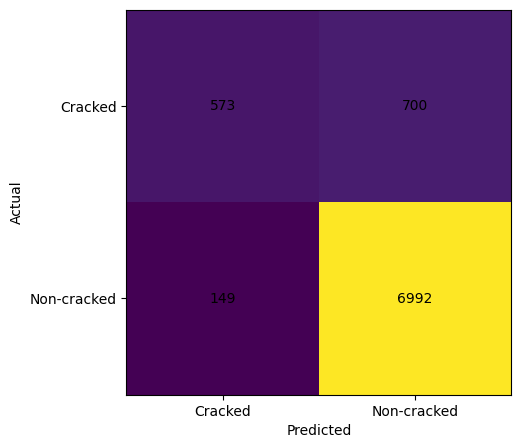

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(cm)

plt.xticks([0,1], ["Cracked","Non-cracked"])
plt.yticks([0,1], ["Cracked","Non-cracked"])

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.show()

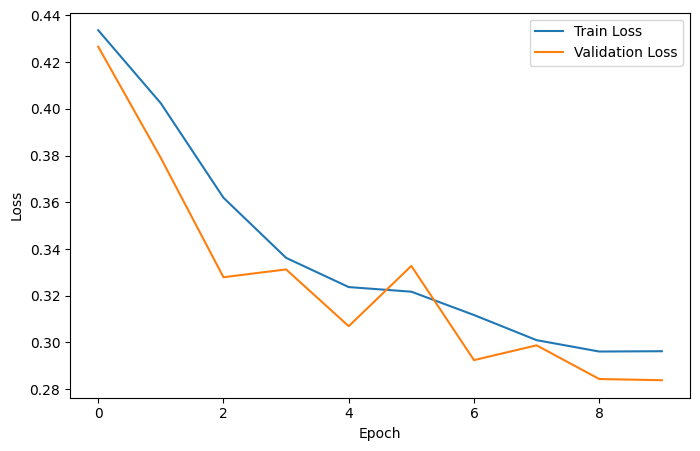

In [57]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

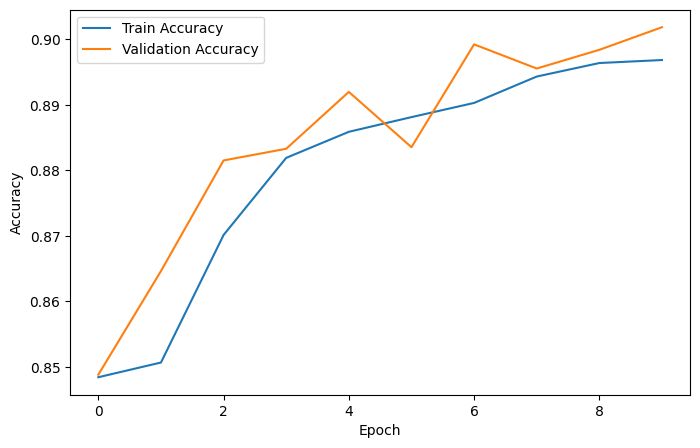

In [58]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [59]:
from PIL import Image

image = Image.open("images.jpeg").convert("RGB")

image = test_transform(image).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    output = model(image)
    prediction = torch.argmax(output, dim=1).item()

print("Prediction:", prediction)

Prediction: 0
